In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib as mpl
import seaborn as sns
import numpy as np
import math
from cycler import cycler
from collections import Counter

In [2]:
def get_group_shares(groups_map: list[dict[str, int]]) -> dict[str, int]:
    """Returns the size of each group in the groups map"""
    c = Counter()
    for group in groups_map:
        c[group["top_category"]] += 1

    # compute share
    total = sum(c.values())
    unique_groups = sorted(list(c.keys()))
    shares = {}
    for group in unique_groups:
        shares[group] = c[group] / total

    return shares

In [3]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.ticker as mticker


def plot_combined_datasets(
    datasets: dict[str, dict],  # {dataset_name: {method_name: results}}
    group_shares_per_dataset: dict[str, dict[str, float]],  # {dataset_name: group_shares}
    groups_key: str,
    n_consumers: int,
    n_producers: int,
    n_runs: int,
    k_rec: int,
    save_path: Path,
) -> None:
    """Plot all datasets in one figure with shared x axes and individual y axes per subplot."""
    sns.set_style("white")
    mpl.rc('font', **{'size': 16})
    plt.rcParams["font.family"] = "Times New Roman"

    dataset_names = list(datasets.keys())
    method_names = list(datasets[dataset_names[0]].keys())
    n_datasets = len(dataset_names)
    n_methods = len(method_names)

    # Build gridspec: rows=datasets, cols=methods + one colorbar column per row
    fig = plt.figure(figsize=(3.5 * n_methods + 0.8, 2.8 * n_datasets), dpi=300, constrained_layout=True)
    gs = fig.add_gridspec(
        nrows=n_datasets,
        ncols=n_methods + 1,
        width_ratios=[1] * n_methods + [0.05],
        wspace=0.12,
        hspace=0.15
    )

    # Create axes with shared x only, each subplot has its own y scale
    axes = np.empty((n_datasets, n_methods), dtype=object)
    for i in range(n_datasets):
        for j in range(n_methods):
            sharex = axes[0, j] if i > 0 else None
            axes[i, j] = fig.add_subplot(gs[i, j], sharex=sharex)

    # Create colorbar axes (one per row)
    cbar_axes = [fig.add_subplot(gs[i, -1]) for i in range(n_datasets)]

    cmap = plt.get_cmap("flare")

    # Plot each dataset row with individual color normalization
    for row_idx, ds_name in enumerate(dataset_names):
        all_results = datasets[ds_name]
        group_shares = group_shares_per_dataset[ds_name]

        # Individual color normalization per dataset
        shares = list(group_shares.values())
        norm = mpl.colors.PowerNorm(gamma=0.5,
                                    vmin=min(shares),
                                    vmax=max(shares))
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        for col_idx, method_name in enumerate(method_names):
            ax = axes[row_idx, col_idx]
            results = all_results[method_name]
            ax.grid(True, linestyle="--", alpha=0.4)

            z = 1
            for group_name, group_dict in results[0].items():
                alpha, alpha_results = next(iter(group_dict.items()))
                xs, ys, ye = [], [], []

                for gamma, runs in sorted(alpha_results.items()):
                    run_means = [np.mean(run) for run in runs]
                    xs.append(float(gamma))
                    ys.append(np.mean(run_means))
                    ye.append(np.std(run_means) / np.sqrt(len(runs)))

                if group_name == "all":
                    ax.plot(xs, ys,
                            color="black", linestyle="dashdot",
                            marker="s", markersize=3,
                            linewidth=1.5, zorder=100,
                            label="Mean")
                else:
                    color = sm.to_rgba(group_shares.get(group_name, 0))
                    ax.plot(xs, ys,
                            label=group_name.replace("_", " ").capitalize(),
                            linewidth=1.5, alpha=0.8,
                            color=color, zorder=z)
                    ax.fill_between(xs,
                                    np.array(ys) - np.array(ye),
                                    np.array(ys) + np.array(ye),
                                    alpha=0.05, zorder=z,
                                    color=color)
                    z += 1

            ax.set_xlim(0, 1.0)
            ax.set_xticks([0, 0.5, 1.0])
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

            # Column titles (method names) only on first row
            if row_idx == 0:
                ax.set_title(method_name.replace("_", " "), fontsize=16)

            # Row labels (dataset names) only on first column
            if col_idx == 0:
                ax.set_ylabel(ds_name, fontsize=15, fontweight='bold')

            # Hide x tick labels except on bottom row
            if row_idx < n_datasets - 1:
                plt.setp(ax.get_xticklabels(), visible=False)

        # Add colorbar for this row
        cbar = fig.colorbar(sm, cax=cbar_axes[row_idx], orientation='vertical')
        if row_idx == n_datasets // 2:
            cbar.set_label("Group size share %", labelpad=10, fontsize=14)

    # Super-labels
    fig.supxlabel(
        r"Fraction of best min producer utility guaranteed, $\gamma$",
        x=0.47, y=-0.04, ha="center", fontsize=16
    )
    fig.text(
        -0.04, 0.5, "Consumer utility",
        va="center", ha="center", rotation="vertical", fontsize=16
    )

    # Save
    filename = f"combined_results_per_gamma_{groups_key}_{n_consumers}_{n_producers}_{n_runs}_{k_rec}.pdf"
    save_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path / filename, bbox_inches='tight')
    plt.show()


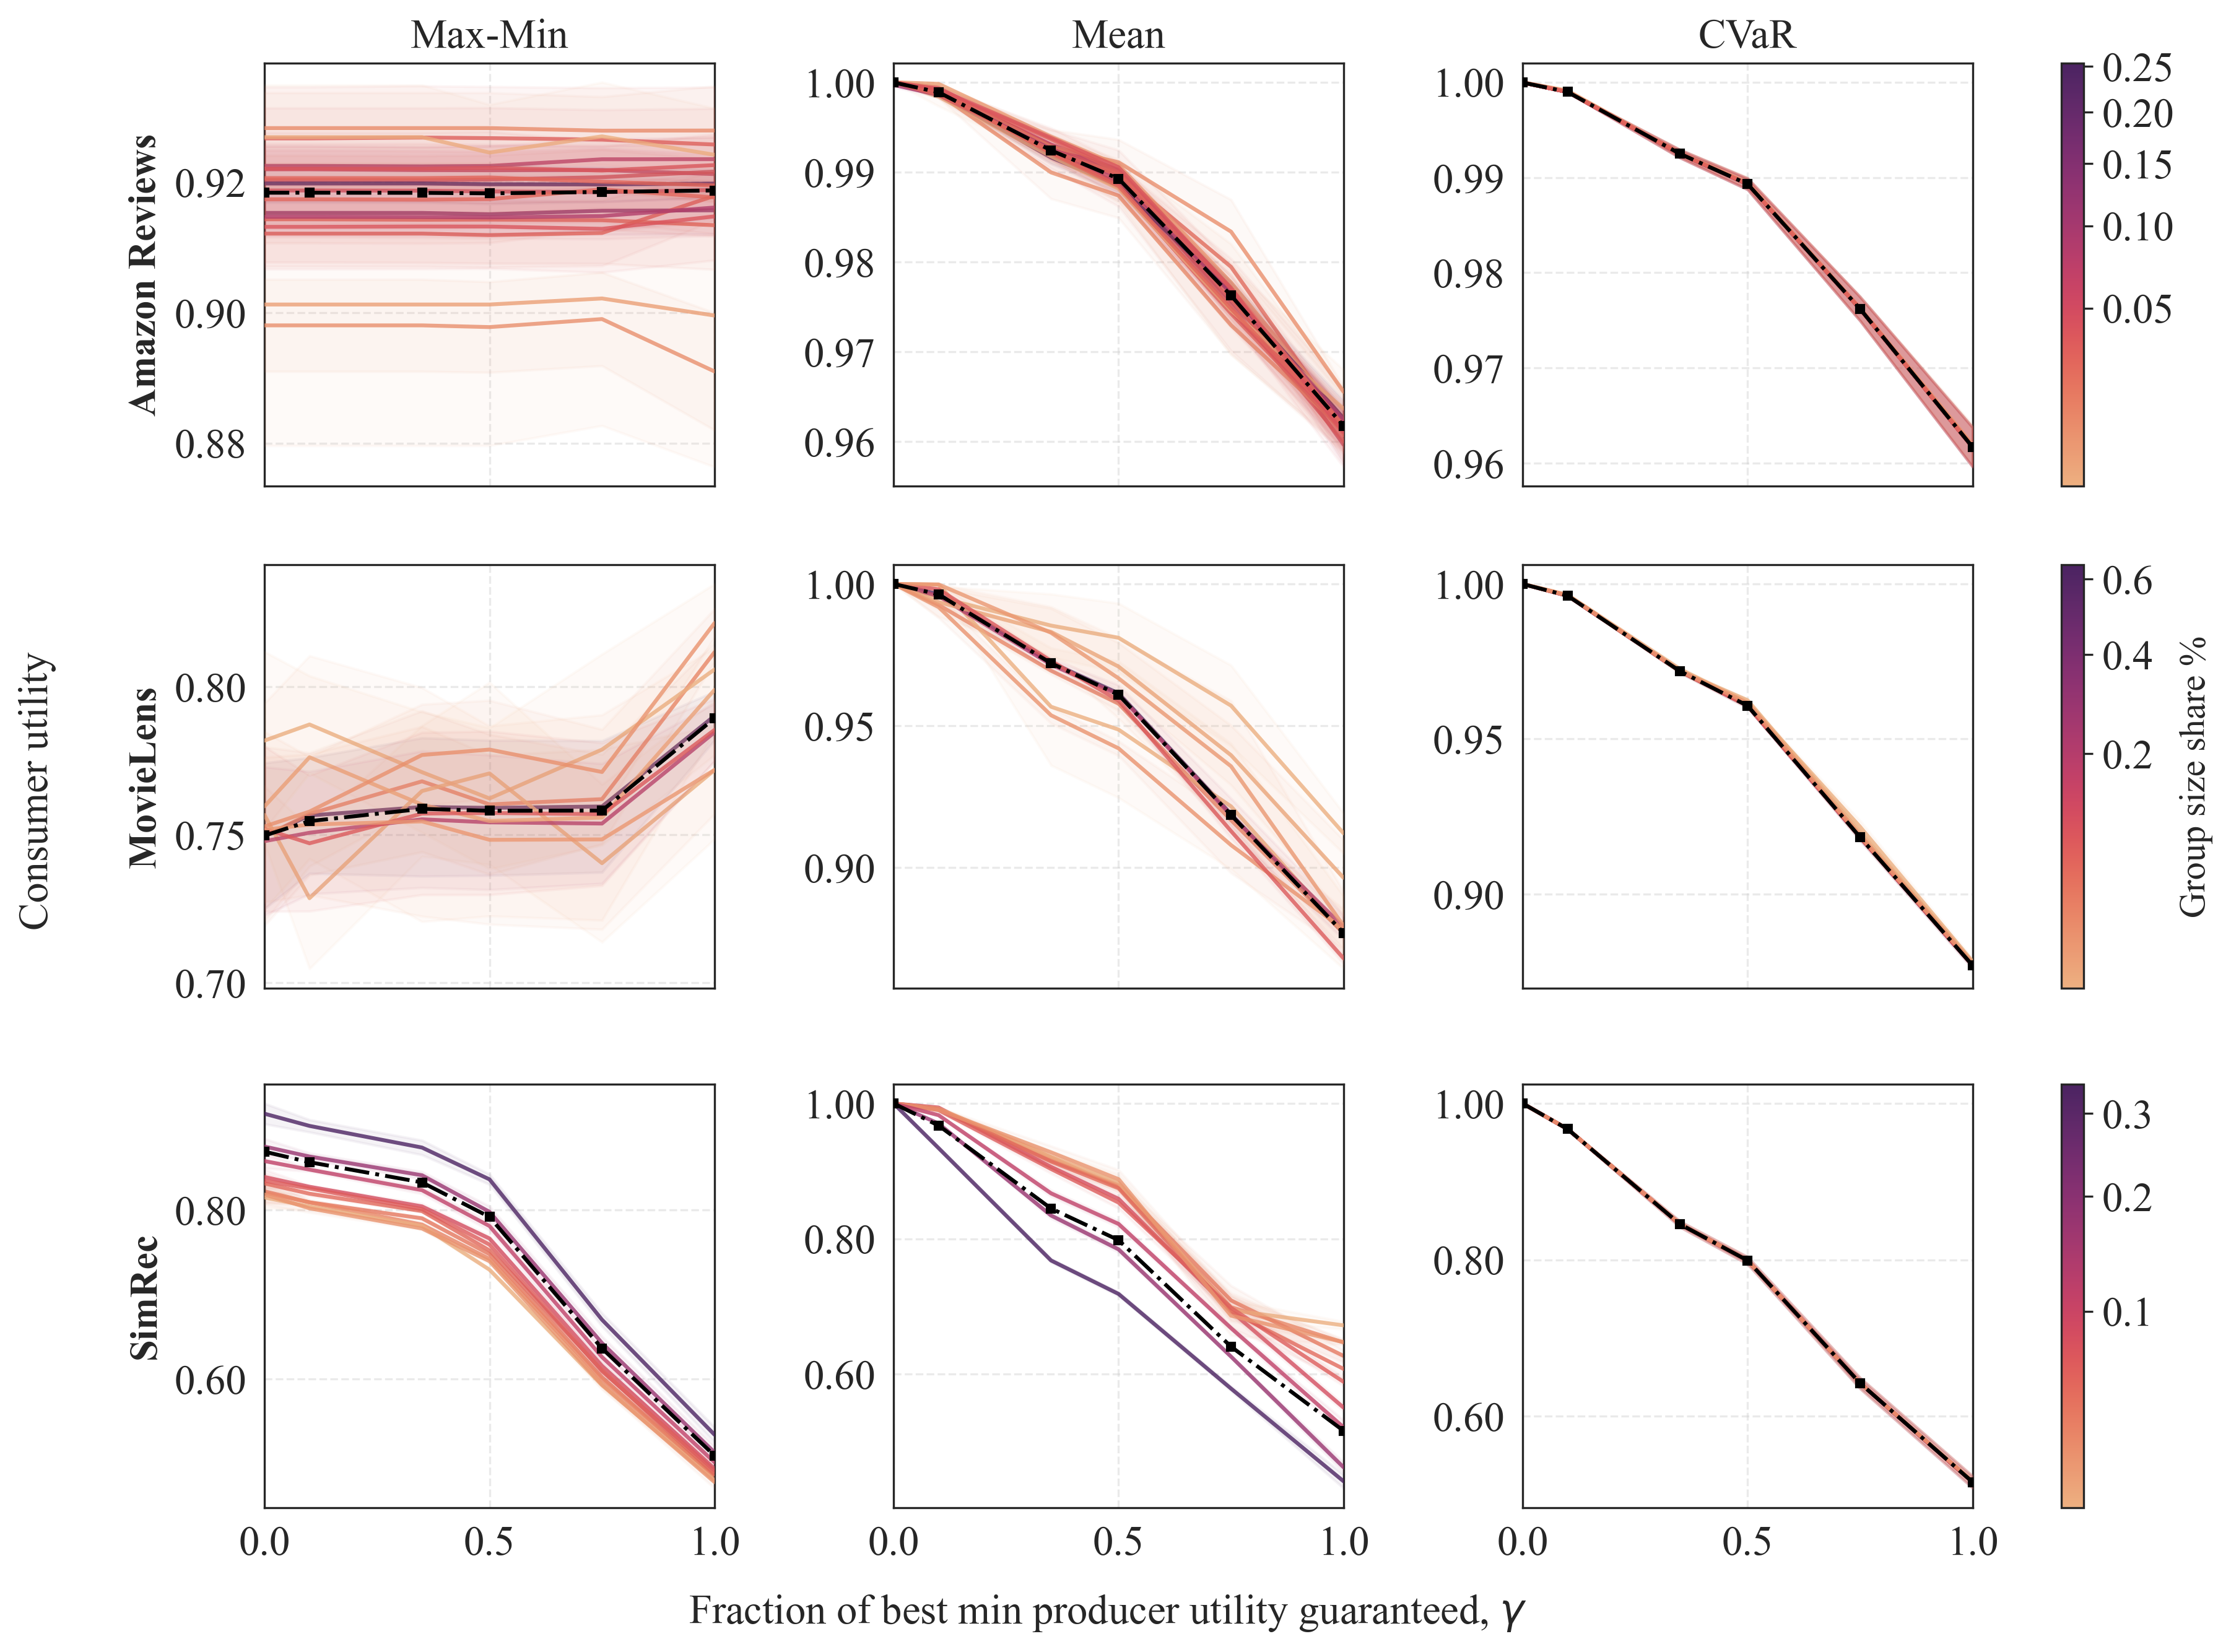

In [4]:
# Load all three datasets

# === MovieLens ===
ROOT_PATH_MOVIELENS = "../../results/1748537493"
with open(f"{ROOT_PATH_MOVIELENS}/movielens_min_top_category_500_500_10_0_0.1_0.35_0.5_0.75_1_0.99.json", "r") as f:
    movielens_min = json.load(f)
with open(f"{ROOT_PATH_MOVIELENS}/movielens_mean_top_category_500_500_10_0_0.1_0.35_0.5_0.75_1_0.99.json", "r") as f:
    movielens_mean = json.load(f)
with open(f"{ROOT_PATH_MOVIELENS}/movielens_cvar_top_category_500_500_10_0_0.1_0.35_0.5_0.75_1_0.99.json", "r") as f:
    movielens_cvar = json.load(f)
with open("../../data/movielens_user_groups.json", "r") as f:
    movielens_groups = json.load(f)
movielens_shares = get_group_shares(movielens_groups)

# === SimRec ===
ROOT_PATH_SIMREC = "../../results/1749821745"
with open(f"{ROOT_PATH_SIMREC}/simrec1_min_top_category_500_500_10_0_0.1_0.35_0.5_0.75_1_0.95.json", "r") as f:
    simrec_min = json.load(f)
with open(f"{ROOT_PATH_SIMREC}/simrec1_mean_top_category_500_500_10_0_0.1_0.35_0.5_0.75_1_0.95.json", "r") as f:
    simrec_mean = json.load(f)
with open(f"{ROOT_PATH_SIMREC}/simrec1_cvar_top_category_500_500_10_0_0.1_0.35_0.5_0.75_1_0.95.json", "r") as f:
    simrec_cvar = json.load(f)
with open("../../data/simrec1_user_groups.json", "r") as f:
    simrec_groups = json.load(f)
simrec_shares = get_group_shares(simrec_groups)

# === Amazon ===
ROOT_PATH_AMAZON = "../../results/1749830495"
with open(f"{ROOT_PATH_AMAZON}/amazon_min_top_category_500_500_10_0_0.1_0.35_0.5_0.75_1_0.95.json", "r") as f:
    amazon_min = json.load(f)
with open(f"{ROOT_PATH_AMAZON}/amazon_mean_top_category_500_500_10_0_0.1_0.35_0.5_0.75_1_0.95.json", "r") as f:
    amazon_mean = json.load(f)
with open(f"{ROOT_PATH_AMAZON}/amazon_cvar_top_category_500_500_10_0_0.1_0.35_0.5_0.75_1_0.99.json", "r") as f:
    amazon_cvar = json.load(f)
with open("../../data/amazon_user_groups.json", "r") as f:
    amazon_groups = json.load(f)
amazon_shares = get_group_shares(amazon_groups)

# Combined plot
datasets = {
    "Amazon Reviews": {
        "Max-Min": amazon_min["results"]["top_category"],
        "Mean": amazon_mean["results"]["top_category"],
        "CVaR": amazon_cvar["results"]["top_category"],
    },
    "MovieLens": {
        "Max-Min": movielens_min["results"]["top_category"],
        "Mean": movielens_mean["results"]["top_category"],
        "CVaR": movielens_cvar["results"]["top_category"],
    },
    "SimRec": {
        "Max-Min": simrec_min["results"]["top_category"],
        "Mean": simrec_mean["results"]["top_category"],
        "CVaR": simrec_cvar["results"]["top_category"],
    },
}

group_shares_per_dataset = {
    "Amazon Reviews": amazon_shares,
    "MovieLens": movielens_shares,
    "SimRec": simrec_shares,
}

plot_combined_datasets(
    datasets=datasets,
    group_shares_per_dataset=group_shares_per_dataset,
    groups_key="top_category",
    n_consumers=500,
    n_producers=200,
    n_runs=5,
    k_rec=10,
    save_path=Path("results"),
)

In [5]:
# Cell no longer needed - combined plot is generated in the cell above

In [6]:
# Cell no longer needed - combined plot is generated above